In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sph import integrate, animate_particles, get_densities

In [2]:
np.random.seed(0)

In [3]:
no_particles = 990
no_steps = 1000
L = 10
h = 0.5
v0 = 1
dt = 0.01
c_s = 10
rho0 = 10
gamma = 7
masses = np.array([1]*no_particles)


initial_positions = np.random.random(size=(no_particles,2))*L
initial_velocities = np.random.normal(size=(no_particles,2))*v0
print(np.mean(np.abs(initial_velocities)))
initial_velocities[:,0] += 10*v0

0.7828218732157861


In [4]:
positions, velocities = integrate(initial_positions, initial_velocities, masses, L, h, c_s, rho0, dt, no_steps)
print(np.mean(np.abs(velocities[10])))

5.710231313524965o go: 0:00:00.339478


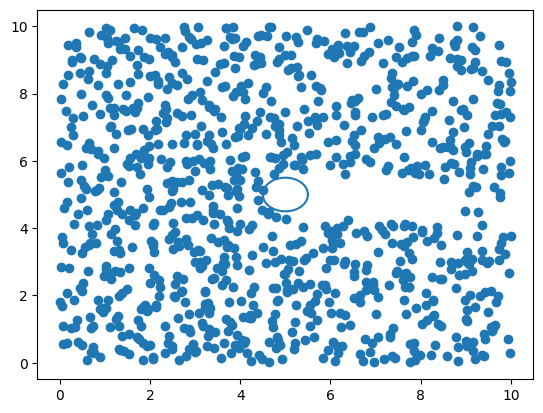

In [5]:
plt.figure()
idx = 99
plt.scatter(positions[idx,:,0], positions[idx,:,1])
theta = np.linspace(0,2*np.pi,100)
plt.plot(L/2+0.5*np.cos(theta),L/2+0.5*np.sin(theta))
#plt.scatter(positions[1,:,0], positions[1,:,1])
#plt.scatter(positions[0,:,0], positions[0,:,1])
#plt.scatter(positions[idx,:,0], positions[idx,:,1])

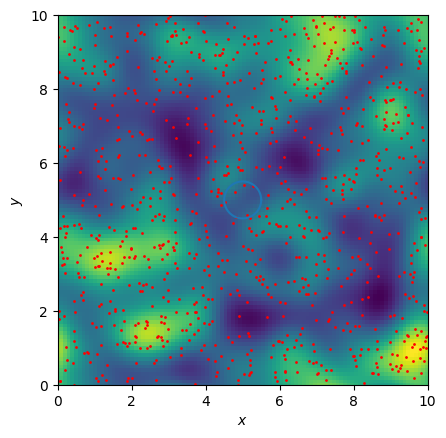

In [ ]:
animate_particles(positions, masses, L, h, fps=30, file_name = "long_flow.mp4")

### Check mass conservation
The mass from integrating the density is slighly smaller than the summed particle masses, since the density grid only takes into account the density from the nearest image of a particle. Since our kernel is gaussian, and thus extends infinitely, there are other images of the particle that still give non-zero  integrated density 

In [ ]:
from sph import get_density_grid

grid_size = 100
dV = (L/grid_size)**2 # volume element
x,y,rho = get_density_grid(positions[0], masses, L, h, grid_size=grid_size)

print(f"Integrated density =  {np.sum(rho*dV):.2f}")
print(f"Summed particle masses = {np.sum(masses):.2f}")

Integrated density =  992.05
Summed particle masses = 990.00


### Energy conservation

39.17088991244306
452.5582233958661


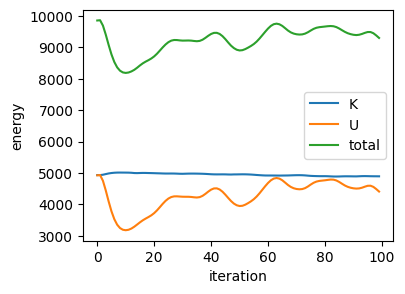

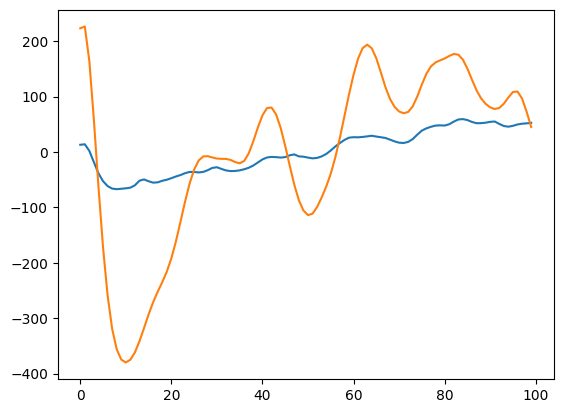

In [ ]:
def u(rho):
    B = c_s**2*rho0/gamma
    return -B/rho0**gamma*(rho**(gamma-1)/(1-gamma)-1/rho)


densities = np.array([get_densities(positions[i], masses, L, h) for i in range(no_steps)])
internal_energies = np.array([u(densities[i]) for i in range(no_steps)])
total_internal_energy = np.sum(internal_energies, axis=1)
kinetic_energies = 1/2*np.sqrt(np.sum(velocities**2,axis=2))
total_kinetic_energy = np.sum(kinetic_energies, axis=1)

fig, ax = plt.subplots(figsize=(4,3))
ax.plot(total_kinetic_energy, label="K")
ax.plot(total_internal_energy, label="U")
ax.plot(total_internal_energy+total_kinetic_energy, label="total")
ax.legend()
ax.set_xlabel("iteration")
ax.set_ylabel("energy")

fig, ax =plt.subplots()
ax.plot((total_kinetic_energy-np.mean(total_kinetic_energy))*-1)
ax.plot((total_internal_energy - np.mean(total_internal_energy))/2.9)
print(np.std(total_kinetic_energy))
print(np.std(total_internal_energy))
plt.show()